In [ ]:
#import numpy as np
import pandas as pd

from neuralforecast import NeuralForecast
import sys
import os
sys.path.append(os.path.abspath("../../"))
# from QNeuralForecast.dlinear import DLinear
# from QNeuralForecast.nhits import NHITS
# from QNeuralForecast.patchtst import PatchTST
# from QNeuralForecast.timesnet import TimesNet
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet
# from neuralforecast.losses.pytorch import MAE
# from torch.optim import Adam

In [41]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)

df = df.sort_values(["Store","Date"])

split_date = "2015-06-01"

train_df = df[df["Date"] < split_date].copy()
val_df   = df[df["Date"] >= split_date].copy()

In [42]:
HORIZON=52
INPUT_SIZE=60
#OPTIMIZER=Adam() # <-- TODO: specify list of params
MAX_STEPS=300

dlinear = DLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    #optimizer=OPTIMIZER
)
nhits = NHITS(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    #optimizer=OPTIMIZER,
)
patchtst = PatchTST(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    #optimizer=OPTIMIZER,
)
timesnet = TimesNet(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    #optimizer=OPTIMIZER,
)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


In [43]:
nf = NeuralForecast(models=[dlinear,nhits,patchtst,timesnet], freq="D")

In [44]:
nf.fit(train_df,
       id_col="Store",
       time_col="Date",
       target_col="Sales",
       verbose=True,
       distributed_config=None)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  3.2 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  3.2 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 6.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.3 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=300` reached.


...

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss           │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train   │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler         │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ model          │ ModuleList    │  4.7 M │ train │     0 │
│ 4 │ enc_embedding  │ DataEmbedding │    192 │ train │     0 │
│ 5 │ layer_norm     │ LayerNorm     │    128 │ train │     0 │
│ 6 │ predict_linear │ Linear        │  6.8 K │ train │     0 │
│ 7 │ projection     │ Linear        │     65 │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 4.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 50                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=300` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Models found: ['index', 'DLinear', 'NHITS', 'PatchTST', 'TimesNet']

Global MAE per model:
TimesNet: 1449.3454
DLinear: 1545.5800
PatchTST: 1568.0088
NHITS: 1573.1820
index: 22845.6394

Top 5 Stores (Best Predicted on Average): [103, 83, 112, 48, 113]


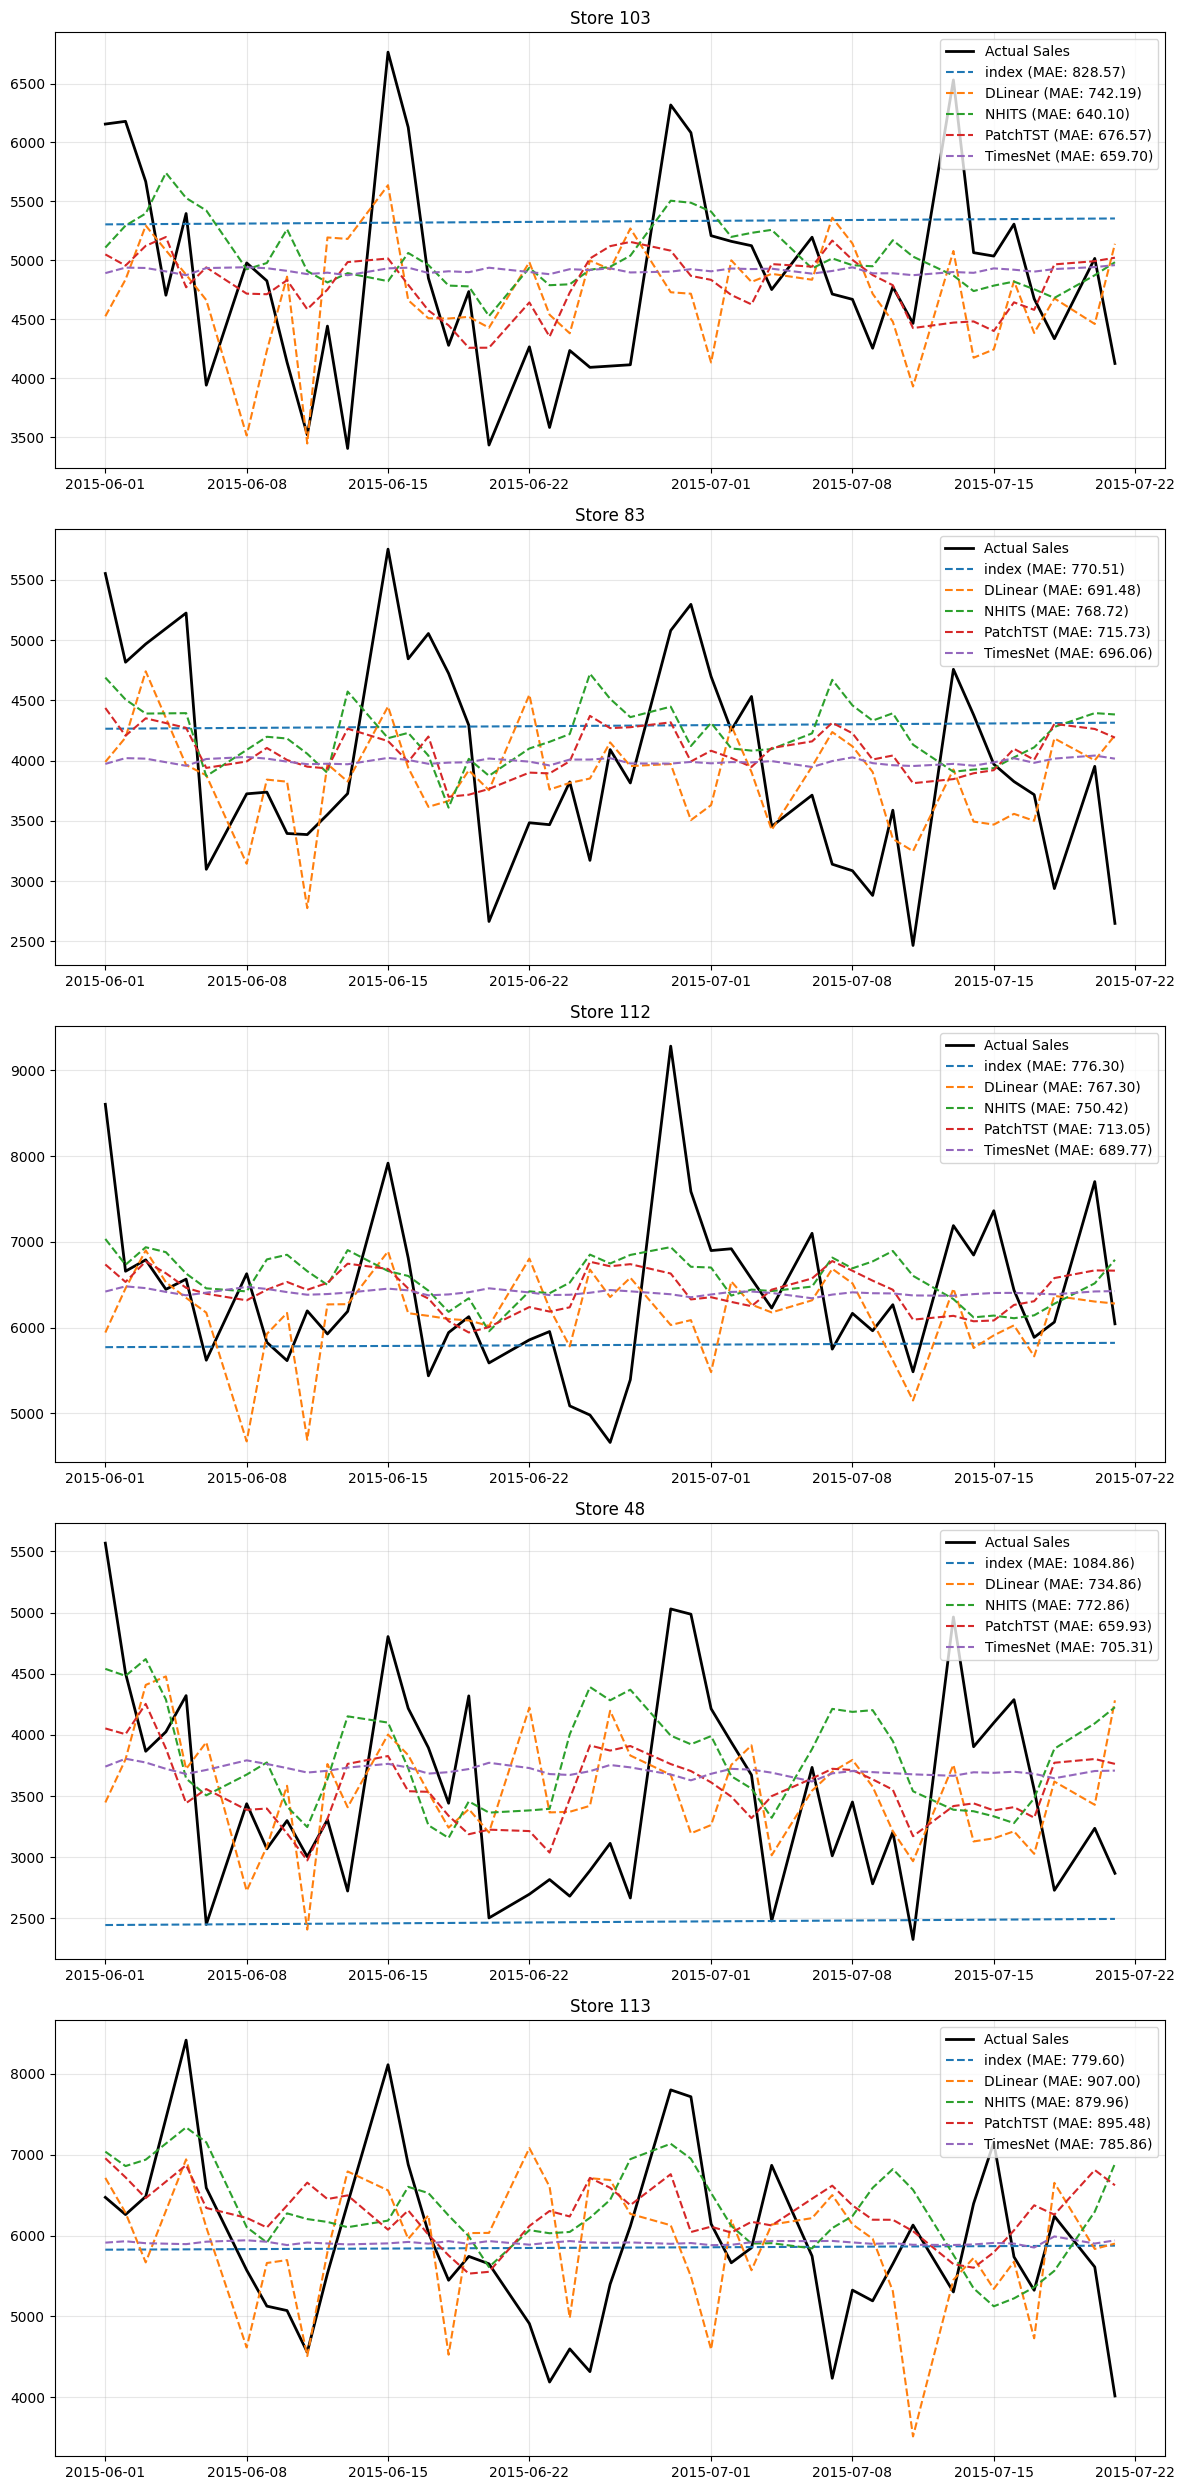

In [39]:
# Predict with all models
forecasts = nf.predict().reset_index()

# Merge with validation values to compare
comparison = val_df[["Store", "Date", "Sales"]].merge(forecasts, on=["Store", "Date"], how="inner")

# Identify the model columns (exclude Store, Date, and Sales if it somehow got in there)
model_names = [col for col in forecasts.columns if col not in ["Store", "Date"]]
print(f"Models found: {model_names}")

# Calculate separate MAE for each model
results = {}
for model in model_names:
    mae = (comparison["Sales"] - comparison[model]).abs().mean()
    results[model] = mae

print("\nGlobal MAE per model:")
for m, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{m}: {score:.4f}")

# Find Top 5 Best Predicted Stores (using average error across all models)
comparison["avg_model_error"] = 0
for model in model_names:
    comparison["avg_model_error"] += (comparison["Sales"] - comparison[model]).abs()
comparison["avg_model_error"] /= len(model_names)

mae_per_store = comparison.groupby("Store")["avg_model_error"].mean().sort_values()
top_5_stores = mae_per_store.head(5).index.tolist()

print(f"\nTop 5 Stores (Best Predicted on Average): {top_5_stores}")

import matplotlib.pyplot as plt

# Plot for the top 5 stores
fig, axes = plt.subplots(5, 1, figsize=(12, 25), sharex=False)

for i, store_id in enumerate(top_5_stores):
    store_data = comparison[comparison["Store"] == store_id]
    
    ax = axes[i]
    # Plot Actual
    ax.plot(store_data["Date"], store_data["Sales"], label="Actual Sales", color='black', linewidth=2)
    
    # Plot each model
    for model in model_names:
        model_mae = (store_data["Sales"] - store_data[model]).abs().mean()
        ax.plot(store_data["Date"], store_data[model], label=f"{model} (MAE: {model_mae:.2f})", linestyle='--')
    
    ax.set_title(f"Store {store_id}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()